# **LAB.4**

In [20]:
import pandas as pd

df = pd.read_csv('/content/Chocolate_Sales.csv')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


# **TASK 1**

In [21]:
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


np.int64(0)



After exploring the dataset using df.info(), df.describe(), and other functions, the following data quality issues were identified:

- The Date column is stored as an object instead of datetime format.
- The Amount column is stored as an object instead of numeric format.
- No missing values were found in the dataset.
- No duplicate rows were detected.

# **TASK 2**

In [22]:
df.fillna(df.median(numeric_only=True), inplace=True)



Although the dataset does not contain missing values, a missing value handling strategy was applied for demonstration purposes.

Median imputation was chosen instead of mean because the dataset contains **outliers** in the Amount column. The median is less sensitive to extreme values, making it a more robust choice for handling missing data.

# **TASK 3**

In [23]:
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True).astype(float)

In [24]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['Amount', 'Boxes Shipped'], dtype='object')

In [25]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} outliers:", len(outliers))

Amount outliers: 50
Boxes Shipped outliers: 78


In [26]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


Before detecting outliers, the Amount column was cleaned and converted from object to numeric format.

Outliers were detected using the IQR method. Values outside the lower and upper bounds were considered outliers.

Capping was applied using the clip() function to limit extreme values while preserving the dataset.

# **TASK 4**

In [27]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['Amount', 'Boxes Shipped'], dtype='object')

In [28]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df[num_cols])

df_minmax.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,0.301826,0.378836
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,0.448166,0.196825
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,0.255299,0.190476
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,0.722553,0.721693
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,0.777033,0.387302


In [29]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[num_cols] = standard_scaler.fit_transform(df[num_cols])

df_zscore.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,-0.157898,0.144261
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,0.442345,-0.581458
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,-0.348735,-0.606773
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,1.567799,1.511311
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,1.791259,0.178015



Two normalization techniques were applied to the numerical features:

1. Min-Max Scaling: This method scales the values between 0 and 1.
2. Z-score Standardization: This method transforms the data to have a mean of 0 and a standard deviation of 1.

These techniques help ensure that all numerical features are on a similar scale, which improves data analysis and model performance.

# **TASK 5**

In [30]:
corr_matrix = df[num_cols].corr()
corr_matrix

,Amount,Boxes Shipped
Amount,1.000000,-0.011804
Boxes Shipped,-0.011804,1.000000


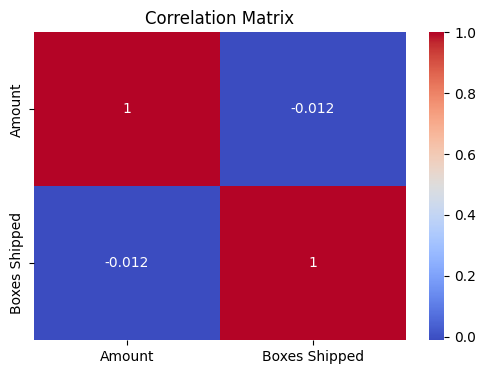

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



The correlation value between Amount and Boxes Shipped is approximately -0.012, which is very close to zero.

This indicates that there is no significant relationship between the two variables.

Therefore, PCA was not applied.